<a href="https://colab.research.google.com/github/Laragb21/PRA3024_BigDataPhysics/blob/main/PRA3024_2026_Cosmology_STUDENTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style='color:deepskyblue'> Cosmology MCMC notebook </span>

## <span style='color:deepskyblue'>Preliminaries</span>

In [ ]:
# Install required packages (if not available on server, uncomment the lines below)

!pip3 install --upgrade pip
!pip3 install getdist
!pip3 install numpy
!pip3 install scipy
!pip3 install matplotlib



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 834.0/834.0 kB 9.4 MB/s  0:00:00


In [ ]:
 #Load required packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.integrate as integrate

# import pylab
import getdist, IPython, time
from numpy import random

# from IPython.display import Image
from getdist import plots, MCSamples, loadMCSamples

# just for printing! calculations should be performed with machine precision
%precision 3

'%.3f'

(NB: Those equations that you will need to build your code are those $\boxed{\text{with a box around}}$)

## <span style='color:deepskyblue'> The $\Lambda$CDM Model </span>

The Lambda-Cold-Dark-Matter ($\Lambda$CDM) Model is our current "Standard" cosmological model. It postulates a Universe that behaves according to **General Relativity**, filled with **baryons** (protons, neutrons - the stuff we and stars are made of!), **Cold Dark Matter (CDM)** and a **Cosmological Constant** $\Lambda$.

The expansion of the Universe is best described in terms of the **scale factor** $a$ (the "radius" of the Universe, conventionally set to 1 today) and the **Hubble rate** $H$

$$
H \equiv \frac{\dot a}{a}
$$
Where the dot signifies a time derivative $\dot a \equiv da/dt $

The Einstein Equations in a **homogeneous and isotropic** Universe have an especially simple form and a special name, **Friedmann Equation**:

$$
H^2 = \frac{8\pi G}{3}\rho + \frac{k}{a^2}
$$

where $\rho$ is the total energy density of the Universe (at a certain time or size), and $k$ is a universal constant related to the [spatial curvature and shape of the Universe](https://en.wikipedia.org/wiki/Shape_of_the_universe#:~:text=The%20spatial%20curvature%20is%20related,indistinguishable%20spaces%20with%20different%20topologies.). In the $\Lambda$CDM model (and at late enough times), this additionally simplifies to

$$
\boxed{
H^2 = H_0^2\left(\Omega_\Lambda + \Omega_m a^{-3} + \Omega_k a^{-2}\right)
}
\qquad
\qquad
\boxed{
\Omega_m + \Omega_\Lambda + \Omega_k = 1
}
$$

$H_0$ is the value of the Hubble rate *today*, and the parameters $\Omega_m$, $\Omega_\Lambda$ and $\Omega_k$ are dimensionless quantities indicating how much of the present expansion of the Universe is due to (non-relativistic) matter, cosmological constant $\Lambda$, and spatial curvature $k$. Note that the three $\Omega$'s are *not independent* (their sum is 1) and that we grouped together the contribution of baryons and CDM,

$$
\Omega_m = \Omega_{\rm CDM} + \Omega_{\rm b}
$$

and that we have evidence that independent evidence that $\Omega_b \approx 5$\%. Note that only $\Omega_m \geq 0$ makes physical sense, while in principle both $\Omega_\Lambda$ and $\Omega_k$ can be negative.
In this consideration we are neglecting the contribution of the radiation which becomes negligable after the early stages of expansion.


The present Hubble rate is conventionally parametrised in terms of the dimensionless $h$:

$$
H_0 \equiv h\, \times 100 \left[\frac{ \,\text{km}}{\text{s Mpc}}\right]
$$

where Mpc = Megaparsec and [parsec](https://en.wikipedia.org/wiki/Parsec)  $pc = 3.086 \cdot 10^{16}$ m.

In essence, these equations give us the relation between *what exists in the Universe* and *how the Universe expanded*. Measure one, I can tell you the other. This is precisely what we aim to do!

Time to define the function $H(z)$. Don't forget to include the useful parameters as arguments of the function, and to define `parsec`.

## <span style='color:orange'> Excersise 1 </span>

Write your own code for the Hubble parameter as a function of redshift (z) note that $a = \frac{1}{1+z}$. Make a plot to see if your function works as expected.

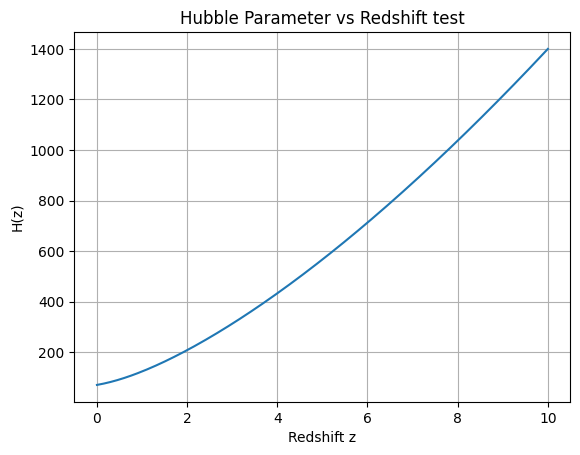

In [ ]:
# Hubble rate

pc= 3.086e16 # [m] parsec
Mpc=pc/10e6 #Mega parsec

def H0_from_h(h):
  return h*100

def a(z):  #scale factor (radius of the universe)
  return 1/(1+z)

def Hubble(z, h, OmegaM, OmegaL):
    H0 = 100.0 * h
    OmegaK = 1.0 - OmegaM - OmegaL
    return H0 * np.sqrt(OmegaM*(1+z)**3 + OmegaK*(1+z)**2 + OmegaL)

#test values for checking if the function works
OmegaM=0.3
OmegaL=0.7
OmegaK=0
h=0.7

z = np.linspace(0, 10, 200)
Hz = Hubble(z, h, OmegaM, OmegaL)
H0 = H0_from_h(h)

plt.plot(z, Hz)
plt.xlabel("Redshift z")
plt.ylabel("H(z)")
plt.title("Hubble Parameter vs Redshift test")
plt.grid()
plt.show()



In this first Exercise, I defined the Hubble function and its Parameters.
The Hubble rate of today H0 is defined on the basis of the h value. The Universie expansion Parameters Omega Lambda, K and M are dimesionless and if added have a value of 1. To test the function, I plotted it against arbitrary redshift and Omega values. The final plot shows a slightly curved but increasing line. This means that the expansion rate of the universe (Hubble) increases at higher redshift and the groth is not linear.

##  <span style='color:deepskyblue'>Supernovae Ia</span>

In order to track the expansion of the Universe, we will look at Supernovae type Ia observations. SNIa are formed when a *white dwarf* accretes matter from a companion until it reaches a critical mass of about $1.44 M_\odot$ (solar masses), after which it explodes **at always the same luminosity** $L_{\rm SN}$. Therefore, the observed [magnitude](https://en.wikipedia.org/wiki/Magnitude_(astronomy)) is only a function of their [**luminosity distance**](https://en.wikipedia.org/wiki/Distance_measures_(cosmology)) from Earth, defined as the ratio of the intrinsic luminosity $L_{\rm SNIa}$ and the measured *surface brightness* $\Phi$ (energy per unit time per unit area)

$$ d_L\equiv \frac{L_{\rm SN}}{4\pi \Phi} $$

While photons (light rays) travel from the distant SNIa to Earth, the Universe expands and the photons get redshifted, and this redshift is directly related to the size of the Universe when the photon was emitted compared to today:

$$ \frac{\lambda_{\rm obs}}{\lambda_{\rm em}} \equiv 1 + z_{\rm em} = \frac{1}{a_{\rm em}}$$

We can express the luminosity distance in terms of the Hubble rate:

$$
\boxed{
d_L(z) = \frac{c}{H_0}(1+z) \times
\begin{cases}
    \cfrac{1}{\sqrt{\Omega_k}} \,\sinh\left(\sqrt{\Omega_k}\,D(z)\right) & \Omega_k > 0
    \\[.5em]
    D(z) & \Omega_k = 0
    \\[.5em]
    \cfrac{1}{\sqrt{-\Omega_k}} \,\sin\left(\sqrt{-\Omega_k}\,D(z)\right) & \Omega_k < 0
\end{cases}
\qquad\qquad
D(z) \equiv H_0\int_0^z \frac{{\rm d}Z}{H(Z)}
}
$$

where $c$ is the speed of light: $c \simeq 2.998 \cdot 10^{5}$ km/s.

Clearly, there exists a relation between $d_L(z)$ and $H(z)$, so the luminosity distance is a useful measure of the Universe expansion history.

We can create the function `dL(z, h, Omega_m, Omega_Lambda)`. You can also pass the function `Hubble` as an argument: `dL(z, Hubble, Omega_m, Omega_Lambda)`. Additionally, you can create $D(z)$ for your convenience.

Note that you need to integrate the function $H(z)$, so write your own quick-and-easy numerical integrator, for example implementin the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule) or your favourite alternative, or [look up the pre-written methods](https://docs.scipy.org/doc/scipy/reference/tutorial/integrate.html). Make sure it returns $d_L$ in parsecs and that it uses $h$, which is $H_0$ measured in units of 100 km/s/Mpc!

## <span style='color:orange'> Excersise 2 </span>

Define a function that calculate the luminosty distance in flat ($\Omega_k = 0$) and both possitively and negatively curved  ($\Omega_k \neq 0$) spacetime.

In [ ]:

c= 2.998e5 #[km/s] speed of light
# H(z)= Hubble function
# D(z) = dimensionlesss comoving distance

from scipy.integrate import quad #importing scipy quad for calculating the integral. python libary for integrations, where quad is a specific integration function


def D(z, H0, OmegaM, OmegaL):
    integrand = lambda zp: 1.0 / Hubble(zp, H0, OmegaM, OmegaL) #lambda defines: For any Z , compute 1/H(Z)
    integral, _ = quad(integrand, 0, z) #quad takes the integrand and computes the integral from 0 to z for integrad function
    return (c / H0) * integral


#defining the luminosity distance, with dependence on the Omega K value
def theor_luminosity_distance(z, h, OmegaM, OmegaL):
    H0 = 100.0 * h
    OmegaK = 1.0 - OmegaM - OmegaL
    Dc = D(z, h, OmegaM, OmegaL)

    if np.isclose(OmegaK, 0.0):
        Dm = Dc
    elif OmegaK > 0:
        Dm = np.sinh(np.sqrt(OmegaK) * Dc * H0 / c) / np.sqrt(OmegaK) * c / H0
    else:
        Dm = np.sin(np.sqrt(-OmegaK) * Dc * H0 / c) / np.sqrt(-OmegaK) * c / H0

    return (1 + z) * Dm



In Exercise 2, I defined the dimensionless comoving distance... to later define the theoretical luminosity distance. For the comoving distance, an integral had to be computed inside the function, for which scipy and quad turned out to be helpful. Lambda here first defines the function that has to be computed in the integra at every z. Afterwards, quad continues to actually compute the area under the curve from 0 to z.
Furthermore, for hte second part of the exercise, I just coded the given formula and since it varies (depends) on the value of Omega k, I used if conditions inside the function.

## <span style='color:deepskyblue'>The Union2.1 Compilation</span>

Our source of data is from [Union2.1](http://supernova.lbl.gov/Union/). It is a collection of $580$ SNIa, each observation is comprised of redshift $z$ and [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus) $\mu$ (and corresponding errors $\delta\mu$), defined as the difference between the *apparent magnitude* $m$ and the *absolute magnitude* $M$:

$$
\boxed{
\mu(z) \equiv m(z) - M \equiv 5 \log_{10} \frac{d_L(z)}{10\,\text{pc}}
}
$$

Our goal today is to use SNIa measurements to constrain the parameters ($h, \Omega_\Lambda, \Omega_m$).

In essence, we can calculate for each redshift the theoretical value of $\mu$ using this equation with the expression for $d_L(z)$ and our model of choice $H(z)$ -- note that we will need to perform a numerical integral! -- and compare this value with observations. A different model would amount to changing the theoretical value of $H(z)$.

Let us start by importing and plotting the data:

In [ ]:
def theor_distance_modulus(dL_Mpc): #mu
    return 5 * np.log10(dL_Mpc) + 25

dataloc = "SCPUnion2.1_mu_vs_z.txt"
data = np.genfromtxt(dataloc) # array: [name, redshift, magnitude, magnitude error, and another number?]


display(data[0]) # Print the first line as an example

array([      nan, 2.849e-02, 3.535e+01, 2.239e-01, 1.284e-01])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
zs = data[:,1] # redshift zs
mu_data = data[:, 2] #magnitudes
mu_err = data[:, 3] #magnitude errors
print(len(zs)) #length


580


Recommendation: plot the data so you can see the luminosity distance and distance modulus as a function of the redshift

## <span style='color:orange'> Excersise 3 </span>

Now also define a function to calculate the distance modulus using your previously defined luminosity distance function. Use these functions to plot the theoretical curves as a function of redshift and compare with the data. (Does the line go through the data points?)

In [ ]:
luminosity_distance_pc = 10. * 10.**(mu_data / 5.)
luminosity_distance_Mpc = luminosity_distance_pc / 10.**6 # and in Mpc
err_luminosity_distance_Mpc = 5. * (10.**((mu_data + mu_err)/5.-6.) - 10.**((mu_data - mu_err)/5.-6.))

Try your functions here. Make atleast two plots to check that for $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$ and $h =0.7$ your theory calculations of the luminosity distance and the distance modulus match okay to the data for redshifts ranging from ~0.1 to 2.

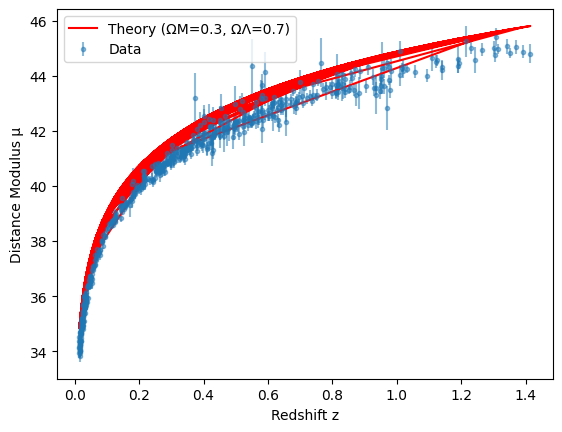

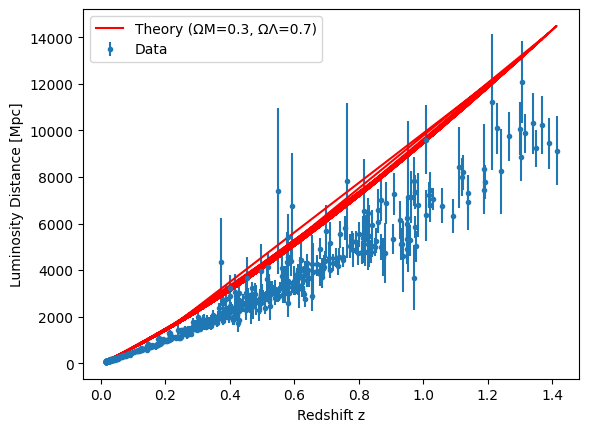

In [ ]:
from numpy.typing import DTypeLike

def theor_distance_modulus(dL_Mpc):
    dL_pc = dL_Mpc * 1e6  # 1 Mpc = 1e6 pc
    return 5 * np.log10(dL_pc / 10)

OmegaM = 0.3 #test values
OmegaL = 0.7
OmegaK=0
h=0.7

# Compute theory once
dL_theory = np.array([theor_luminosity_distance(z, h, OmegaM, OmegaL) for z in zs])
dm_theory = theor_distance_modulus(dL_theory)

# Plot distance modulus μ(z)
plt.errorbar(zs, mu_data, yerr=mu_err, fmt='o', markersize=3, alpha=0.5, label="Data")
plt.plot(zs, dm_theory, color='red', label="Theory (ΩM=0.3, ΩΛ=0.7)")
plt.xlabel("Redshift z")
plt.ylabel("Distance Modulus μ")
plt.legend()
plt.show()

# Plot luminosity distance dL(z)
plt.errorbar(zs, 10**((mu_data/5.)-5), yerr=err_luminosity_distance_Mpc, fmt='o', markersize=3, label='Data')  # Mpc
plt.plot(zs, dL_theory, color='red', label="Theory (ΩM=0.3, ΩΛ=0.7)")
plt.xlabel("Redshift z")
plt.ylabel("Luminosity Distance [Mpc]")
plt.legend()
plt.show()


In Exercise 3, the actual data file comes into play. After downloading the text file and copying its path, it could be analyzed. Then the distance modulus function was defined, where it was important to convert pc into Mpc. The test values for Omega and h remained unchanged.
Then in order to make two plots, one of the distance modulus (mu) and one of the luminosity distance as a function of redshift z, luminosity distances and distance modulus has to be computed into an array. To do so, np.array and a for ... in condition were used so that for every redshift z in the data, the luminosity distance and modulus could be caluclated and then listed in the array.

The data points are shown with error bars for uncertainties and the theoretical prediction with the defined testvalues are overlaid in red.

In [ ]:
%matplotlib inline


## <span style='color:deepskyblue'>Bayes' Theorem: Likelihood, Prior, Posterior (and Evidence...)</span>

The **conditional probability of A given that B is true** is denoted with $P(A|B)$ (read: *probability of A given B*).
Did A happen? Then B has probability $P(B|A)$ of happening.

[**Bayes' Theorem**](https://en.wikipedia.org/wiki/Bayes%27_theorem) is simply a reflection of the symmetry of the concept of joint probability:

$$
P(A|B)P(B) = P(B|A)P(A)
$$

In physics, our goal is often to determine how likely the values of some parameters $\theta$ are, given how well they reproduce the data $D$.
We write Bayes' theorem in the following equivalent form:

$$
P(\theta | D) = \frac{P(D|\theta)P(\theta)}{P(D)}
$$

The various terms conventionally take the names:

$$
\begin{aligned}
P(\theta | D) & && \text{Posterior}
\\
P(D | \theta)& && \text{Likelihood}
\\
P(\theta) & && \text{Prior}
\\
P(D) & && \text{Evidence}
\end{aligned}
$$

### <span style='color:deepskyblue'>Prior</span>

The *prior* quantifies our degree of prior belief in the model parameters. It can contain the results of previous experiments, or theoretical considerations (for instance, that certain parameters cannot be negative, etc.).

We can have *strong priors* about something - the Sun still existing at night, see the comic below - or not.
When we do *not* have compelling prior knowledge about a parameter, we generally use a *non-informative* prior probability distribution, most often related to the [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution)

$$
\begin{aligned}
    \text{Uniform} & && \theta \in \text{Uniform}[\theta_{\rm min}, \theta_{\rm max}]
    \\
    \text{Log Uniform} & && \log\theta \in \text{Uniform}[\log\theta_{\rm min}, \log\theta_{\rm max}]
\end{aligned}
$$

You may sometimes hear that "the prior doesn't matter". While this is not strictly true, it is however true that in many instances the *likelihood* depends more dramatically on the parameters and will have a dominating contribution to the posterior. You are more than welcome to try different priors for the model parameters and see if and how your results change.

### <span style='color:deepskyblue'>Likelihood</span>

The measure of how well our model reproduces the data is the **likelihood** $\mathcal L$. For normal (=Gaussian), uncorrelated data $\mu_i$ with errors $\sigma_i$ ($i = \{1,580\}$), the likelihood is related to the famous [**chi-squared**](https://en.wikipedia.org/wiki/Chi-square_distribution) via

$$
P(D | \theta) \equiv \mathcal L = \exp\left(-\frac{\chi^2}{2}\right)
\qquad
\qquad
\boxed{
\chi^2 \equiv \sum_{i=1}^{580} \frac{\left(\mu_i^{(\rm theor)} - \mu_i^{(\rm obs)}\right)^2}{\sigma_i^2}
}
$$

A *high likelihood* corresponds to a *low chi squared*.

In principle, we could attack the problem brute-force: create a grid of values for $h$, $\Omega_m$, $\Omega_\Lambda$, calculate the likelihood for each combination, and create a profile for the likelihood.

In practical cases, however, this is not only sub-optimal but sometimes **impossible**. Think of complicated models with 20+ free parameters (this is not that unusual in physics, by the way). Even a very coarse grained grid of 100 values for each parameter would result in more than$10^{40}$ (!!!) different parameter combination to be tested. You can probably understand why this is undesirable.

### <span style='color:deepskyblue'>Evidence</span>

This is the tricky bit. The evidence, which is "*the probability of observing certain data*", is not something that is easy to evaluate or interpret. This looks like a serious limitation to finding the:


### <span style='color:deepskyblue'>Posterior</span>

What does the data tell us about the model parameters? The answer is the *posterior probability distribution*, often (but not necessarily) expressed as (average $\pm$ standard deviation)

$$
\theta_i = \bar\theta_i \pm \sigma_i
$$

In other words, the posterior tells us how likely it is for the model parameters to have certain values, *given that we observe the data* $D$.

*This is the final goal of our analysis!*

<br>

![title](http://1.bp.blogspot.com/-tTx4HDejSww/ULcTeK9_V_I/AAAAAAAAA8g/PCYOH-eXGbk/s1600/frequentists_vs_bayesians.png)
![title](https://i.redd.it/5r0hwixt0m931.jpg)

## <span style='color:deepskyblue'>Markov-Chain Monte Carlo</span>

Markov-Chain Monte Carlo techniques are a class of methods to sample a probability distribution $P(x)$ - in our case $P(\theta | D)$ - provided that we can calculate a density $\mathcal F(x)$ **that is proportional to it** - in our case $P(\theta)P(D|\theta)$ = likelihood $\times$ prior. Among these, a very popular one is the [**Metropolis-Hastings**](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) algorithm, which is what we will use.

Schematically, the algorithm works as follows:
* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and calculate the $\mathcal F_{\rm old}$
* Propose a new set of parameters $\theta_{\rm prop}$, calculate the new corresponding $\mathcal F_{\rm prop}$. How you propose the new parameters is not essential as long as the probability of going from one set of parameters to the next is the same as the inverse: $P(\theta_a \to \theta_b) = P(\theta_b \to \theta_a)$. For this, we normally take Gaussian displacements with some (relatively small) standard deviation.
* Compare the new and old likelihoods-priors:
    * If $\mathcal F_{\rm prop} > \mathcal F_{\rm old}$, accept the step: $\theta_{\rm new} = \theta_{\rm prop}$
    * Otherwise, accept with probability $P_{\rm accept} = \mathcal F_{\rm prop}/\mathcal F_{\rm old}$
* If accepted, $\theta_{\rm new} = \theta_{\rm prop}$ and record the step; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Update $\theta_{\rm old} = \theta_{\rm new}$
* Repeat

The MC chain keeps going until the desired number of steps or, ideally, when a suitable convergence test, like for example the [Gelman-Rubin test](https://bookdown.org/rdpeng/advstatcomp/monitoring-convergence.html), is satisfied.
Today we will just set a limit to the total number of steps, but please feel free to implement and test your favourite convergence test!

Looking at equation (4), you can convince yourself that
$$
\frac{\mathcal L_a}{\mathcal L_b} = \exp\left(\frac{\chi_b^2 - \chi_a^2}{2}\right)
$$

(This is useful because $\chi^2$ can be large, so we want to avoid the likelihoods evaluating to `0.` -- computers don't like dividing by zero, unfortunately)

* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and the corresponding chi squared $\chi_{\rm old}^2$ (to be clear, for us this implies calculating a series of 580 integrals and comparing each with the observed values)
* Propose new parameters $\theta_{\rm prop}$ and calculate the corresponding chi squared $\chi_{\rm prop}^2$
* Draw a random number $r \in [0,1]$
* Accept the step if
$$
r < \exp\left(\frac{\chi_{\rm old}^2 - \chi_{\rm prop}^2}{2}\right) \frac{P(\theta)_{\rm prop}}{P(\theta)_{\rm old}}
$$
* If accepted, update $\theta_{\rm old} = \theta_{\rm prop}$, and record; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Repeat

##  <span style='color:orange'> Excersise 4 </span>

Write your own code to perform a Monte Carlo Markov Chain. Note that your algorithm should be robust and converge to the correct parameters even for poor initial guesses.

In [ ]:

def calculate_chi2(zs, mu_data, mu_err, h, OmegaM, OmegaL):
    mu_model = [] #empty list

    for z in zs: #for every redshift in redshifts
        dL = theor_luminosity_distance(z, h, OmegaM, OmegaL) #distance modulus dL
        mu_model.append(theor_distance_modulus(dL)) #filling the list

    mu_model = np.array(mu_model) #making an array of the list

    if np.any(np.isnan(mu_model)): #if calculation fails for any z, function returns inf
        return np.inf

    chi2 = np.sum(((mu_data - mu_model) / mu_err)**2)

    return chi2



Here the function of chi squared was defined. The function returns a number representing the deviation between data and model.

In [ ]:
from random import random
from random import gauss
import sys

data = np.genfromtxt("SCPUnion2.1_mu_vs_z.txt")

zs = data[:, 1]
mu_data = data[:, 2]
mu_err = data[:, 3]

N_steps = 30000 #defines how many iterations the chain will run

# Initial guesses
h = 0.6
OmegaM = 0.4
OmegaL = 0.6

# Proposal widths
step_h = 0.005
step_OM = 0.01
step_OL = 0.01

chi2_current = calculate_chi2(zs, mu_data, mu_err, h, OmegaM, OmegaL)

accepted = 0
total = 0

#The  MCMC
print("Running MCMC...")
start = time.time()

file = open("MC_Chain_SNIa.txt", "w")

for i in range(N_steps):

    total += 1

    # Propose new parameters
    h_new = gauss(h, step_h)
    OM_new = gauss(OmegaM, step_OM)
    OL_new = gauss(OmegaL, step_OL)
   # Proposed values
    h_new = gauss(h, step_h)
    OM_new = gauss(OmegaM, step_OM)
    OL_new = gauss(OmegaL, step_OL)

# Physical priors first
    if h_new <= 0 or OM_new < 0 or OL_new < 0 or OM_new + OL_new > 1.5:
        continue


    if OM_new + OL_new > 2:
        continue

    chi2_new = calculate_chi2(zs, mu_data, mu_err,
                              h_new, OM_new, OL_new)

    delta = chi2_new - chi2_current

    # Metropolis-Hastings step
    if delta < 0 or random() < np.exp(-0.5 * delta):

        h = h_new
        OmegaM = OM_new
        OmegaL = OL_new
        chi2_current = chi2_new
        accepted += 1

    # Save chain
    file.write(f"{h} {OmegaM} {OmegaL} {chi2_current}\n")

    if i % 5000 == 0: #periodic progress print (not necessary)
        print(f"Step {i}")

file.close()

end = time.time()

print("Done!")
print("Acceptance ratio =", accepted / total)
print("Time required: {:.2f} s".format(end - start))

Running MCMC...
Step 0
Step 5000
Step 10000
Step 15000
Step 20000
Step 25000
Done!
Acceptance ratio = 0.30046666666666666
Time required: 1221.00 s


In exercise 4, the Metropolis-Hasting MCMC is set up, based on the supernova distance modulus data. Firstly the data is loaded using numpys genfromtxt function, to acceys the file created earlier. Then the data categories are identified seperately --> zs is in the first colum mu in the second and mu error in the third.

The initial guess is defined for each parameter and the step values (step_h, etc.) set the proposal widths for the gaussian random walk.If the widths are too large, the acceptance rate will be too low and if they are too small then not all data are explored. Based on this the values where chosen?

Another for loop iterates over the total number of MCMC steps and then the new parameters are proposed, based on the gaussian distribution function (was imported) and the current value.

To make sure that the new parameters are physically significant, jprioirs were implemented with if conditions. if the new values were negative or added together more than 1.5 the program skips to the next iteration and ignores it (=continue).

The new chi2 can be calculated with the previously defined function. Then the Metropolis-Hastings criterion was defined, which is about the difference between new and current chi. if delta is negative, unconditional acceptance, otherwise the acceptance is only with a probability of -0.5delta chi^2.

The periodic progress print does not carry out a functionn in the code itself. It only gives the user an idea, how long the code still needs to run, which was practical for me, since it ran for 20min sometimes.

The Acceptance ratio was 0.30046666666666666, which is a reasonable value, since he chain is accepting a fair number of steps but still exploring new regions of parameter space.

After completion of the programme, your MC chain will (*hopefully*) look something like this:

`#Omega_m  Omega_L  h`

`0.297     0.703    0.698`

`0.285     0.715    0.701`

`0.288     0.712    0.699`

`...`

In [ ]:
import os
print(os.listdir())
#checking if a file was created and where it was stored

['.config', 'SCPUnion2.1_mu_vs_z.txt', 'MC_Chain_SNIa.txt', 'sample_data']


## <span style='color:deepskyblue'>Plotting: GetDist</span>

We will do the plots with [`GetDist`](https://getdist.readthedocs.io/en/latest/plot_gallery.html).

The plot gallery contains a lot of useful examples, you should be able to read them fairly easily and see which applies to your situation. Look for both (triangle) plots and for parameter estimation.

Note that many `GetDist` functions require arguments of type `MCSamples`; make sure you convert your lists accordingly.

##  <span style='color:orange'> Excersise 5 </span>

Use the GetDist functions in the example given underneath but with your **own** MCMC data to generate investigate the sampling of the MCMC.

(21000, 4)
Removed no burn in
0.83  <  h  <  0.84  at  68 % CL
0.21  <  OmegaM  <  0.33  at  68 % CL
0.58  <  OmegaL  <  0.83  at  68 % CL
-0.15  <  OmegaK  <  0.21  at  68 % CL




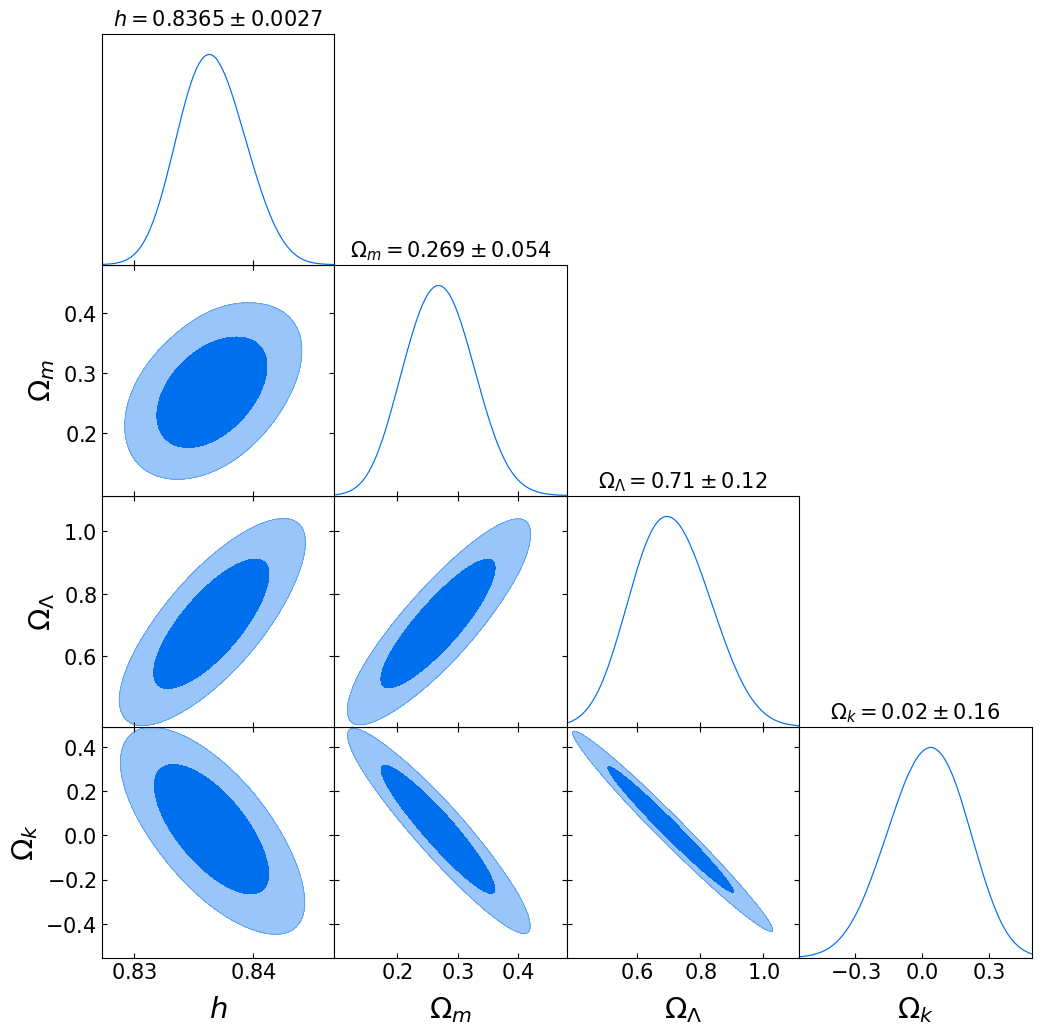

In [ ]:
filename = "MC_Chain_SNIa.txt"
datafile = np.loadtxt(filename,
                      skiprows=int(0.3 * N_steps)) # remove some burn-in

h, OmegaM, OmegaL, chi2 = datafile[:,0],datafile[:,1],datafile[:,2],datafile[:,3]

# You can easily create new np.arrays that are functions of other np.arrays
OmegaK = 1. - OmegaM - OmegaL
# Let's define variable names and labels
my_labels = [r'h', r'\Omega_m', r'\Omega_\Lambda', r'\Omega_k']
my_names = ['h', 'OmegaM', 'OmegaL', 'OmegaK']
my_dim = len(my_names) # The number of variables we're plotting

# This creates a higher-dimensional array with all our data, shaped in the appropriate way...
my_samples = np.transpose(np.reshape([h, OmegaM, OmegaL, OmegaK], (my_dim, len(h))))
print(np.shape(my_samples))

# ... to create an "MCSamples" data type, which GetDist can use
my_samples = MCSamples(samples = my_samples, labels = my_labels, names = my_names)

# The usual 1-sigma confidence level. You can change to 2- or 3-sigma if you want
conf_level = 0.6827

# This prints a table with the 1D posteriors (confidence levels)
for nam in my_names:
    print(round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=False),2), \
          " < ", nam , " < ", round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=True),2),\
          " at " , int(100*conf_level),"\b% CL")
print("\n")

#Triangle corner plot
j = plots.getSubplotPlotter(subplot_size=3)
j.settings.axes_labelsize = 22
j.settings.axes_fontsize = 16
j.triangle_plot(my_samples, filled = True, title_limit=1)

In [ ]:
print(datafile.shape)
print(h[:5])
print(type(h), h.dtype)
print("Shapes:", h.shape, OmegaM.shape, OmegaL.shape, chi2.shape)


(21000, 4)
[0.836 0.836 0.836 0.834 0.834]
<class 'numpy.ndarray'> float64
Shapes: (21000,) (21000,) (21000,) (21000,)


In [ ]:
print(my_samples.getParamNames())

h	h
OmegaM	\Omega_m
OmegaL	\Omega_\Lambda
OmegaK	\Omega_k



In [ ]:
print(filename)

MC_Chain_SNIa.txt


##  <span style='color:orange'> Excersise 6 </span>

Show the curves for $d_L$ and/or $\mu$ as a function of redshift using the best fit parameters determined using your MCMC code, so you will need to make use of your earlier defined functions for $d_L$ and $\mu$ . Check if this correctly reproduces the data. Additionally, provide an extimate on the error and plot the corresponding confidence intervals based on the sample that your MCMC code produces.

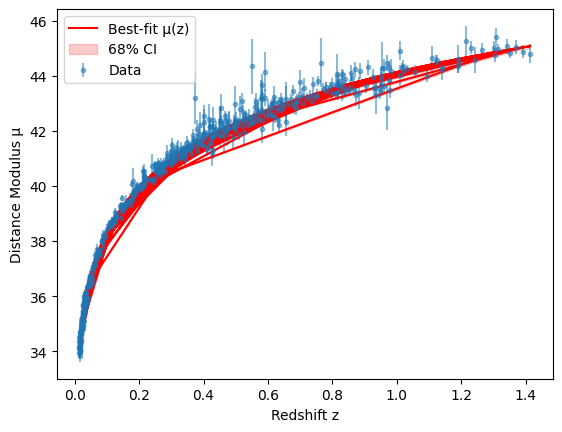

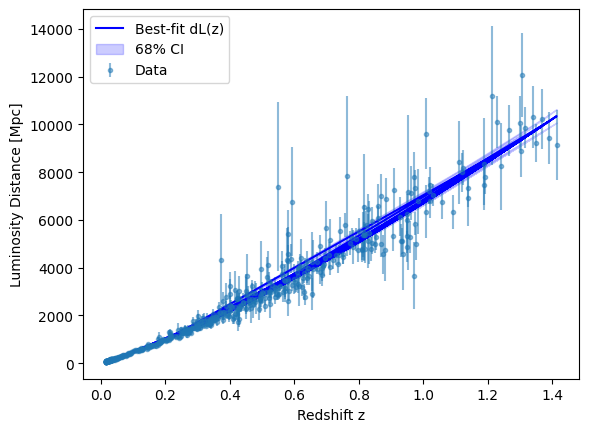

In [ ]:
samples_array = my_samples.samples  # shape: (N_samples, 3)
h_samples = samples_array[:,0] #extracting the MCMC samples h
OmegaM_samples = samples_array[:,1]
OmegaL_samples = samples_array[:,2]
n_samples = len(h_samples) #how many MCMC samples are there?

mu_samples = np.zeros((n_samples, len(zs))) #numpy array filled with zeros (empty, so that it can be filled within the for loop)
dL_samples = np.zeros((n_samples, len(zs)))

for i in range(n_samples):
    h_s = h_samples[i]
    OM_s = OmegaM_samples[i] #placeholder
    OL_s = OmegaL_samples[i]

#computing theor_luminosity_distance for each z
    dL_s = np.array([theor_luminosity_distance(z, h_s, OM_s, OL_s) for z in zs])
    mu_s = theor_distance_modulus(dL_s) #conversion to distance modulus

    dL_samples[i,:] = dL_s #the ith row of dL_samples
    mu_samples[i,:] = mu_s

# Best fit median curves
h_best = np.median(h_samples)
Omega_M_best = np.median(OmegaM_samples) #best fit of mu
Omega_L_best = np.median(OmegaL_samples)

dL_best = np.array([theor_luminosity_distance(z, h_best, Omega_M_best, Omega_L_best) for z in zs])
mu_best = theor_distance_modulus(dL_best)

#Confidence intervals
mu_lower = np.percentile(mu_samples, 16, axis=0) #lower 68% CI
mu_upper = np.percentile(mu_samples, 84, axis=0) #upper 68% CI
dL_lower = np.percentile(dL_samples, 16, axis=0)
dL_upper = np.percentile(dL_samples, 84, axis=0)

#Plots
plt.errorbar(zs, mu_data, yerr=mu_err, fmt='o', markersize=3, alpha=0.5, label="Data")
plt.plot(zs, mu_best, color='red', label="Best-fit μ(z)")
plt.fill_between(zs, mu_lower, mu_upper, color='red', alpha=0.2, label="68% CI")
plt.xlabel("Redshift z")
plt.ylabel("Distance Modulus μ")
plt.title("Best-fit μ(z)")
plt.legend()
plt.show()

plt.errorbar(zs, 10**((mu_data/5.)-5), yerr=err_luminosity_distance_Mpc, fmt='o', markersize=3, alpha=0.5, label="Data")
plt.plot(zs, dL_best, color='blue', label="Best-fit dL(z)")
plt.fill_between(zs, dL_lower, dL_upper, color='blue', alpha=0.2, label="68% CI")
plt.xlabel("Redshift z")
plt.ylabel("Luminosity Distance [Mpc]")
plt.title("Best-fit dL(z)")
plt.legend()
plt.show()

In Exercise 6, the MCMC samples are used to compute the theoretical curves of the luminosity distance and distance modulus.

the samples are extracted from my_ssamples and then stored as arrays. The for loops make sure rhe samples are computed for each sample to get the uncertainty bands.

The plots show the data and the best-fit curve as well as the 68% Confidence interval for both functions.

Generally the plots confim that there is a consistency of the CDM model with the data and the best-fit curves accurately reproduce the supernova distance measurements.